In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import statsmodels.api as sm
pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')
HS_data['date'] = pd.to_datetime(HS_data['date'])

dt4training = HS_data.loc[HS_data['type'] =='dt4training']
dt4testing = HS_data.loc[HS_data['type'] =='dt4testing']

Summer Model

In [ ]:
#Creating summer DV and Interaction variables
HS_data['summer_DV'] = np.where(HS_data['date'].dt.month.isin([6, 7, 8]), 1, 0)

HS_data['summer_Interaction'] = HS_data['production'] * HS_data['summer_DV']

#Updating training and testing sets to include the new summer DV and Interaction variables
dt4training = HS_data.loc[HS_data['type'] =='dt4training'].copy()
dt4testing = HS_data.loc[HS_data['type'] =='dt4testing'].copy()

#Setting dependent and independent variables
y = dt4training.loc[:, 'revenue']
x = dt4training.loc[:, ['production', 'summer_DV', 'summer_Interaction']]

#Creating summerModel
x = sm.add_constant(x)
summerModel = sm.OLS(y, x).fit()

#Testing summerModel
x_test = dt4testing.loc[:, ['production', 'summer_DV', 'summer_Interaction']]

x_constant = sm.add_constant(x_test)

summerModel.predict(x_constant)

summerModel_assessment = dt4testing.copy()

summerModel_assessment['summerModel_predicted_revenue'] = summerModel.predict(x_constant)

summerModel_assessment['pct_error'] = abs((
    summerModel_assessment['revenue'] - summerModel_assessment['summerModel_predicted_revenue'])/summerModel_assessment['revenue'])

#Finding MAPE Score of summerModel
summerModel_assessment['pct_error'].mean()

np.float64(0.19680284631043443)

Summer Model Visualization

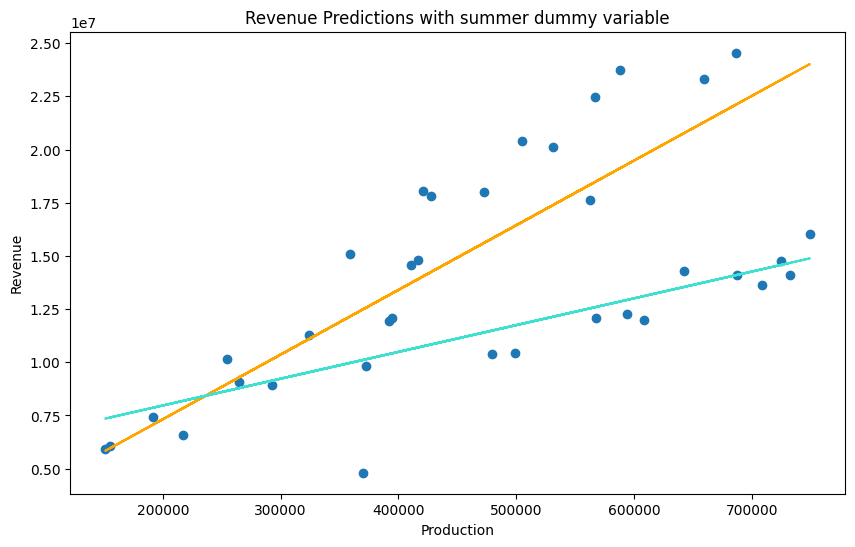

In [ ]:
plt.figure(figsize = (10, 6))

plt.title('Revenue Predictions with summer dummy variable')
plt.xlabel('Production')
plt.ylabel('Revenue')

#Step 1 for visualizing a regression with dummy variables is to scatterplot the actual datapoints

plt.scatter(dt4training['production'], dt4training['revenue'])

#Step 2 is to extract the coefficient from our models
intercept, production_coefficient, summer_DV_Intercept, summer_Coefficient = summerModel.params

#Step 3 is to create individual lines for summer and non-summer

non_summer_line = intercept + production_coefficient * dt4training['production']

summer_line = (intercept + summer_DV_Intercept) + (production_coefficient + summer_Coefficient) * dt4training['production']

#Step 4 plot the y values against the x values for out intercept

plt.plot(dt4training['production'], non_summer_line, color = 'orange')
plt.plot(dt4training['production'], summer_line, color = 'turquoise')

Spring Model

In [ ]:
#Creating spring DV and Interaction variables
HS_data['spring_DV'] = np.where(HS_data['date'].dt.month.isin([3, 4, 5]), 1, 0)

HS_data['spring_Interaction'] = HS_data['production'] * HS_data['spring_DV']

#Updating training and testing sets to include the new spring DV and Interaction variables
dt4training = HS_data.loc[HS_data['type'] =='dt4training'].copy()
dt4testing = HS_data.loc[HS_data['type'] =='dt4testing'].copy()

#Setting dependent and independent variables
y = dt4training.loc[:, 'revenue']
x = dt4training.loc[:, ['production', 'spring_DV', 'spring_Interaction']]

#Creating springModel
x = sm.add_constant(x)
springModel = sm.OLS(y, x).fit()

#Testing springModel
x_test = dt4testing.loc[:, ['production', 'spring_DV', 'spring_Interaction']]

x_constant = sm.add_constant(x_test)

springModel.predict(x_constant)

springModel_assessment = dt4testing.copy()

springModel_assessment['springModel_predicted_revenue'] = springModel.predict(x_constant)

springModel_assessment['pct_error'] = abs((
    springModel_assessment['revenue'] - springModel_assessment['springModel_predicted_revenue'])/springModel_assessment['revenue'])

#Finding MAPE Score of springModel
springModel_assessment['pct_error'].mean()

np.float64(0.2892751835381226)

Spring Model Visualization

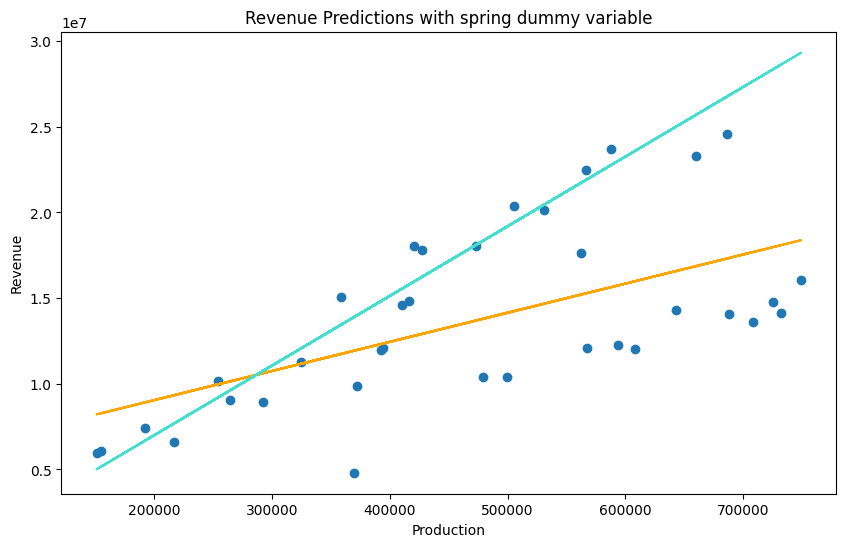

In [ ]:
plt.figure(figsize = (10, 6))

plt.title('Revenue Predictions with spring dummy variable')
plt.xlabel('Production')
plt.ylabel('Revenue')

#Step 1 for visualizing a regression with dummy variables is to scatterplot the actual datapoints

plt.scatter(dt4training['production'], dt4training['revenue'])

#Step 2 is to extract the coefficient from our model
intercept, production_coefficient, spring_DV_Intercept, spring_Coefficient = springModel.params

#Step 3 is to create individual lines for spring and non-spring

non_spring_line = intercept + production_coefficient * dt4training['production']

spring_line = (intercept + spring_DV_Intercept) + (production_coefficient + spring_Coefficient) * dt4training['production']

#Step 4 plot the y values against the x values for out intercept

plt.plot(dt4training['production'], non_spring_line, color = 'orange')
plt.plot(dt4training['production'], spring_line, color = 'turquoise')

Memo:

Models were created by first dividing them into Summer months (June,July, and August/Months 6, 7, and 8) and Spring months (March, April, and May/Months 3, 4, and 5). Afterwards, the summer and spring DV variables dnoted whether the month was a summer or spring month respectively, outputing a 1 if true and a 0 if false. The summer and spring models were then made to attempt to predict that revenues would be depending on whether the season was or was not summer or whether the season was or was not spring, respectively.

Overall, the summer model was more accurate, as it had a lower MAPE score of 19.68% compared to the spring model's MAPE score of 28.93%. The summer model is recommended.